In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = "/content/drive/MyDrive/UG_Research/Gauri_Project/Dataset_Train_Test/Training"
test_dir  = "/content/drive/MyDrive/UG_Research/Gauri_Project/Dataset_Train_Test/Testing"

IMG_SIZE = 224   # ✅ increased
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Test samples:", test_gen.samples)

Found 5600 images belonging to 4 classes.
Found 1599 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train samples: 5600
Test samples: 1599


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)   # ✅ improves stability
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_eff = Model(inputs=base_model.input, outputs=outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history = model_eff.fit(
    train_gen,
    validation_data=test_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 4685s 13s/step - accuracy: 0.7061 - loss: 0.7649 - val_accuracy: 0.7855 - val_loss: 0.6010 - learning_rate: 1.0000e-04
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.8068 - loss: 0.4967 - val_accuracy: 0.8349 - val_loss: 0.5475 - learning_rate: 1.0000e-04
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - accuracy: 0.8448 - loss: 0.4184 - val_accuracy: 0.8443 - val_loss: 0.5266 - learning_rate: 1.0000e-04
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.8637 - loss: 0.3553 - val_accuracy: 0.8599 - val_loss: 0.4834 - learning_rate: 1.0000e-04
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 100s 286ms/step - accuracy: 0.8768 - loss: 0.3223 - val_accuracy: 0.8718 - val_loss: 0.4538 - learning_rate: 1.0000e-04
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.8879 - loss: 0.2981 - val_accuracy: 0.8768 - val_loss: 0.4320 - learning_rate: 1.0000e-04
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
# Unfreeze top layers
base_model.trainable = True

for layer in base_model.layers[:-30]:   # ✅ unfreeze more layers
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),  # ✅ slightly higher than before
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_eff.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 145s 332ms/step - accuracy: 0.8484 - loss: 0.4037 - val_accuracy: 0.8693 - val_loss: 0.4686 - learning_rate: 3.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.8888 - loss: 0.3008 - val_accuracy: 0.8768 - val_loss: 0.4415 - learning_rate: 3.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 291ms/step - accuracy: 0.9023 - loss: 0.2632 - val_accuracy: 0.8956 - val_loss: 0.4186 - learning_rate: 3.0000e-05
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.9127 - loss: 0.2214 - val_accuracy: 0.9024 - val_loss: 0.4077 - learning_rate: 9.0000e-06
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - accuracy: 0.9159 - loss: 0.2156 - val_accuracy: 0.9024 - val_loss: 0.4074 - learning_rate: 9.0000e-06


In [ ]:
model_eff.evaluate(test_gen)

100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8693 - loss: 0.4686


[0.4685986638069153, 0.8692933320999146]

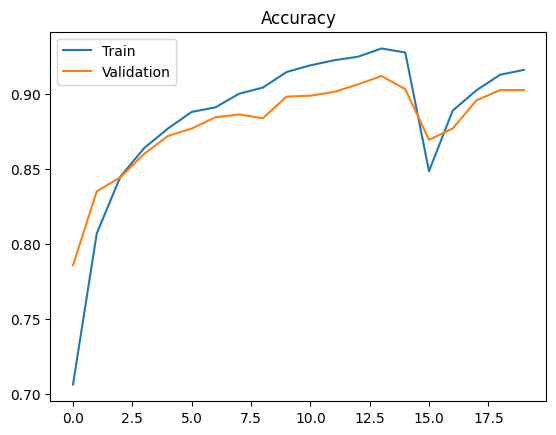

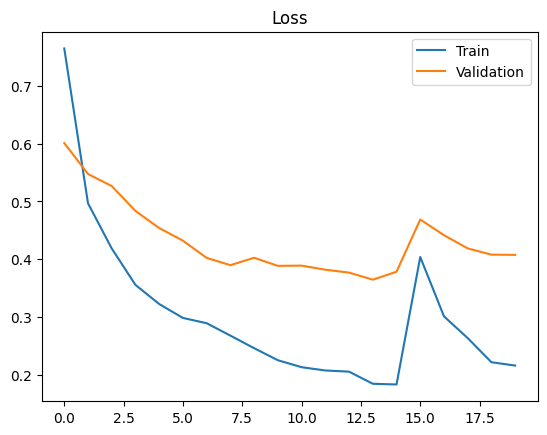

100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step
              precision    recall  f1-score   support

           0       0.94      0.71      0.81       400
           1       0.81      0.79      0.80       399
           2       0.88      0.99      0.93       400
           3       0.86      0.99      0.92       400

    accuracy                           0.87      1599
   macro avg       0.87      0.87      0.87      1599
weighted avg       0.87      0.87      0.87      1599



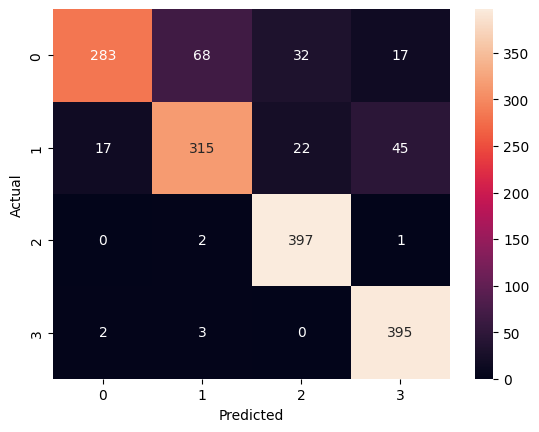

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'] + history_ft.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_ft.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'] + history_ft.history['loss'])
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss")
plt.show()

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = test_gen.classes
y_pred = np.argmax(model_eff.predict(test_gen), axis=1)

print(classification_report(y_true, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step


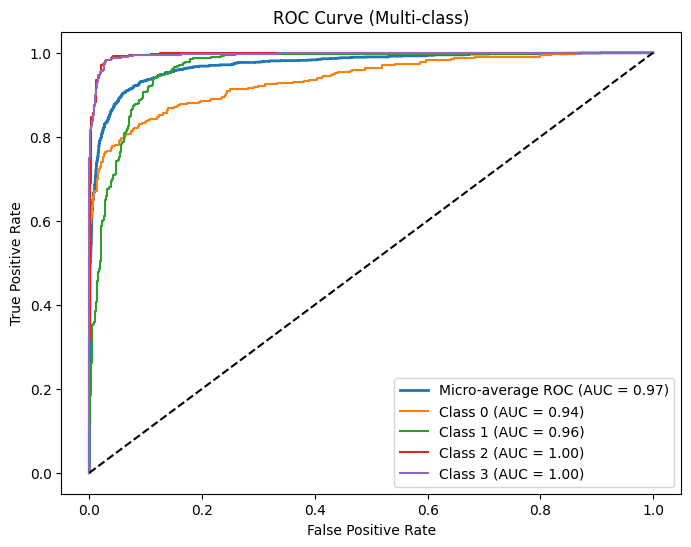

Class 0 AUC: 0.9360
Class 1 AUC: 0.9637
Class 2 AUC: 0.9960
Class 3 AUC: 0.9959
Micro-average AUC: 0.9724


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
# True labels
y_true = test_gen.classes

# Predicted probabilities
y_pred_probs = model_eff.predict(test_gen)

# Number of classes
n_classes = y_pred_probs.shape[1]

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_pred_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.figure(figsize=(8,6))

# Micro-average curve
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})",
    linewidth=2
)

# Per-class curves
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.2f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.4f}")

print(f"Micro-average AUC: {roc_auc['micro']:.4f}")

Model save files moved to 'Shared Folder' --> "/content/drive/MyDrive/UG_Research/Gauri_Project/model_files"

In [ ]:
model_eff.save('/content/drive/MyDrive/model files/EfficientNetB0.h5')

In [ ]:
model_eff.save('/content/drive/MyDrive/model files/EfficientNetB0.keras')